<a href="https://colab.research.google.com/github/kjmm22/logos-ai-devs/blob/development/KM_NeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas

# Total params: 8,370 Accuracy 98.05%

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 📚 LIBRERÍAS
import os
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, utils
from torchsummary import summary
import random
import numpy as np
import matplotlib.pyplot as plt

# ⚙️ CONFIGURACIÓN
# 📁 Rutas de training
trn_csv_path = '/content/drive/MyDrive/Colab Notebooks/AI for Developers/new_model.csv'
trn_img_dir = '/content/drive/MyDrive/Colab Notebooks/AI for Developers/Normal'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Dispositivo:", device)

# 🔁 TRANSFORMACIONES
#transform = transforms.Compose([
#    transforms.Resize((84, 42)),
#    transforms.CenterCrop((80, 40)),
#    transforms.Grayscale(num_output_channels=1),
#    transforms.ToTensor()
#])
transform = transforms.Compose([
    transforms.Resize((84, 42)),
    transforms.RandomCrop((80, 40)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 📂 DATASET
class CustomDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        label = int(row['label'])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label, row['filename']

#CARGA CSV
img_dir = trn_img_dir
df = pd.read_csv(trn_csv_path, header=None)
df.columns = ['filename', 'label']
dataset = CustomDataset(df, img_dir, transform=transform)

#SPLIT
train_dataset, val_dataset = random_split(dataset, [int(0.8 * len(dataset)), len(dataset) - int(0.8 * len(dataset))])
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# 🧠 MODELO CNN
class ImprovedNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, 5, padding=2), nn.BatchNorm2d(8), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))  # 📏 Output: (32, 1, 1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 64), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = ImprovedNet().to(device)
summary(model, input_size=(1, 80, 40))

# 📉 ENTRENAMIENTO
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

# 🔁 TRAIN + VALIDATE

def train_epoch(loader):
    model.train()
    total_loss = 0
    for X, y, _ in loader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item() * X.size(0)
    return total_loss / len(loader.dataset)

def evaluate_and_visualize(loader):
    model.eval()
    total_loss = 0
    correct = 0
    acc_list = []
    all_samples = []

    with torch.no_grad():
        for X, y, fname in loader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss = loss_fn(pred, y)
            total_loss += loss.item() * X.size(0)
            predicted = pred.argmax(1)

            for i in range(X.size(0)):
                acc_list.append((predicted[i] == y[i]).item())
                correct += (predicted[i] == y[i]).item()
                all_samples.append((X[i].cpu(), y[i].item(), predicted[i].item(), fname[i]))

    # 🎯 Sample 20 random items for visualization
    selected_samples = random.sample(all_samples, min(20, len(all_samples)))

    # 🖼️ Display in 4x5 grid
    fig, axes = plt.subplots(4, 5, figsize=(15, 8))
    axes = axes.flatten()

    for i, (img_tensor, label, pred, fname) in enumerate(selected_samples):
        img = img_tensor.squeeze().numpy()
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"{fname}\nPred: {pred} | Real: {label}", fontsize=8)
        axes[i].axis('off')

    for i in range(len(selected_samples), len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    acc = 100 * correct / len(loader.dataset)
    std_dev = np.std(acc_list) * 100
    return acc, total_loss / len(loader.dataset), std_dev

# 🚀 ENTRENAMIENTO
best_acc = 0.0
val_acc_history = []
std_dev_history = []

for epoch in range(20):
    train_loss = train_epoch(train_loader)
    val_acc, val_loss, std_dev = evaluate_and_visualize(val_loader)
    val_acc_history.append(val_acc)
    std_dev_history.append(std_dev)
    scheduler.step(val_acc)
    print(f"Epoch {epoch+1}/20 | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | Std Dev: {std_dev:.2f}%")
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), '/content/drive/MyDrive/km_mininet.pth')
        print(f"💾 Modelo guardado con {best_acc:.2f}%")

print(f"\n🏁 Entrenamiento finalizado. Mejor accuracy: {best_acc:.2f}%")

# 📊 Mostrar parámetros del modelo
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📦 Total de parámetros entrenables: {total_params:,}")

# 📈 Promedios de la corrida completa
avg_acc = np.mean(val_acc_history)
avg_std = np.mean(std_dev_history)
print(f"\n📊 Promedio de Validación Accuracy: {avg_acc:.2f}%")
print(f"📉 Promedio de Desviación Estándar: {avg_std:.2f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dispositivo: cuda
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 80, 40]             208
       BatchNorm2d-2            [-1, 8, 80, 40]              16
              ReLU-3            [-1, 8, 80, 40]               0
         MaxPool2d-4            [-1, 8, 40, 20]               0
            Conv2d-5           [-1, 16, 40, 20]           1,168
       BatchNorm2d-6           [-1, 16, 40, 20]              32
              ReLU-7           [-1, 16, 40, 20]               0
         MaxPool2d-8           [-1, 16, 20, 10]               0
            Conv2d-9           [-1, 32, 20, 10]           4,640
      BatchNorm2d-10           [-1, 32, 20, 10]              64
             ReLU-11           [-1, 32, 20, 10]               0
AdaptiveAvgPool2d-

# TESTING WITH THE NEW DATA!

# Model with 8,300 parameters

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dispositivo: cuda
✅ Modelo cargado
🔍 Total de imágenes en evaluación: 200

🎯 Accuracy sobre los cantos: 99.50%
📉 Desviación estándar: 7.05%


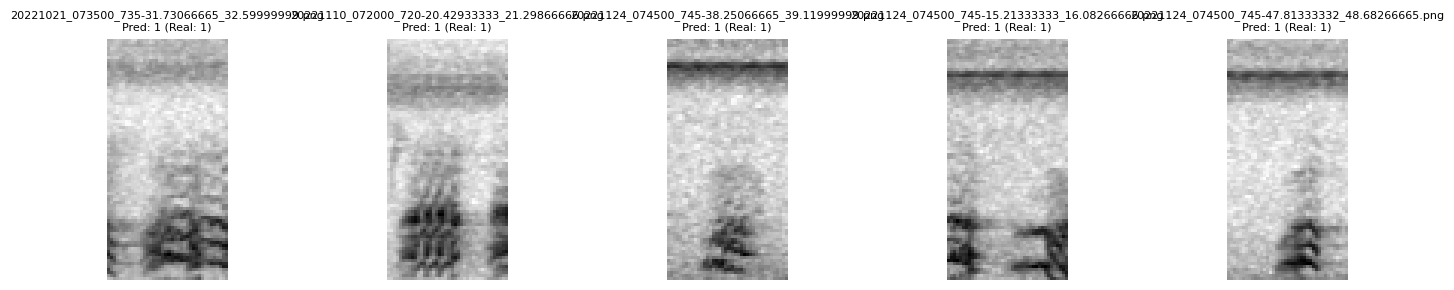

In [ ]:
# 🔗 Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 📚 LIBRERÍAS
import os
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import random
import matplotlib.pyplot as plt
import numpy as np

# ⚙️ CONFIGURACIÓN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Dispositivo:", device)

# 📁 Rutas
eval_csv_path = '/content/drive/MyDrive/Colab Notebooks/AI for Developers/Prueba 2/data.csv'
eval_img_dir = '/content/drive/MyDrive/Colab Notebooks/AI for Developers/Prueba 2/Imagenes'

# 🔁 TRANSFORMACIONES
#transform = transforms.Compose([
#    transforms.Resize((84, 42)),
#    transforms.CenterCrop((80, 40)),
#    transforms.Grayscale(num_output_channels=1),
#    transforms.ToTensor()
#])
transform = transforms.Compose([
    transforms.Resize((84, 42)),
    transforms.RandomCrop((80, 40)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 📂 DATASET
class EvalDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['fileName'])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        # Asumimos que todas las imágenes tienen label = 1
        label = 1
        return image, label, row['fileName']

# 🧠 MODELO
class ImprovedNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, 5, padding=2), nn.BatchNorm2d(8), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 64), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# 📦 Cargar modelo
model = ImprovedNet().to(device)

model.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/km_mininet.pth', map_location=device))
model.eval()
print("✅ Modelo cargado")

# 📊 Iniciar evaluación
df_eval = pd.read_csv(eval_csv_path)
eval_dataset = EvalDataset(df_eval, eval_img_dir, transform=transform)
eval_loader = DataLoader(eval_dataset, batch_size=16, shuffle=False)
print(f"🔍 Total de imágenes en evaluación: {len(eval_dataset)}")

# 🔍 Evaluar y visualizar
def evaluate_inference(loader):
    model.eval()
    correct = 0
    acc_list = []
    samples = []

    with torch.no_grad():
        for X, y, fname in loader:
            X, y = X.to(device), y.to(device)
            preds = model(X).argmax(1)
            for i in range(len(preds)):
                pred = preds[i].item()
                label = y[i].item()  # canto 1
                acc = (pred == label)
                acc_list.append(acc)
                correct += acc
                samples.append((X[i].cpu(), pred, label, fname[i]))

    accuracy = 100 * correct / len(loader.dataset)
    std_dev = np.std(acc_list) * 100

    print(f"\n🎯 Accuracy sobre los cantos: {accuracy:.2f}%")
    print(f"📉 Desviación estándar: {std_dev:.2f}%")

    # Mostrar 5 imágenes aleatorias
    selected = random.sample(samples, min(5, len(samples)))
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    for i, (img, pred, label, fname) in enumerate(selected):
        axes[i].imshow(img.squeeze(), cmap='gray')
        axes[i].set_title(f"{fname}\nPred: {pred} (Real: {label})", fontsize=8)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# 🚀 Ejecutar
evaluate_inference(eval_loader)